In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv("../dataset/medicine_sales.csv")
df.head()


,Date,Store_ID,Item_ID,Medicine_Name,Category,Base_Price,Promotion,Holiday,Units_Sold
0,2025-04-16,Claire Drughouse,M108,Amoxicillin,Antibiotic,180,0,1,74
1,2025-04-10,SmartMed Pharmacy,M104,Vitamin C,Vitamin,120,1,0,85
2,2025-04-10,SmartMed Pharmacy,M109,Azithromycin,Antibiotic,220,1,0,74
3,2025-10-29,Chen Drugstore,M110,Cetirizine,Allergy,40,1,0,111
4,2025-10-25,Apollo Pharmacy,M115,Calcium Tablet,Supplement,250,0,0,81


In [2]:
df.shape

(5000, 9)

In [3]:
df.columns

Index(['Date', 'Store_ID', 'Item_ID', 'Medicine_Name', 'Category',
       'Base_Price', 'Promotion', 'Holiday', 'Units_Sold'],
      dtype='object')

In [4]:
df.info()  #Check data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           5000 non-null   object
 1   Store_ID       5000 non-null   object
 2   Item_ID        5000 non-null   object
 3   Medicine_Name  5000 non-null   object
 4   Category       5000 non-null   object
 5   Base_Price     5000 non-null   int64 
 6   Promotion      5000 non-null   int64 
 7   Holiday        5000 non-null   int64 
 8   Units_Sold     5000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 351.7+ KB


In [5]:
df.isnull().sum() #Check missing values

Date             0
Store_ID         0
Item_ID          0
Medicine_Name    0
Category         0
Base_Price       0
Promotion        0
Holiday          0
Units_Sold       0
dtype: int64

In [6]:
df.duplicated().sum() #Check duplicates

np.int64(0)

In [7]:
df.describe()

,Base_Price,Promotion,Holiday,Units_Sold
count,5000.000000,5000.000000,5000.000000,5000.00000
mean,157.616000,0.303800,0.101400,82.43680
std,139.208521,0.459943,0.301888,15.92158
min,25.000000,0.000000,0.000000,37.00000
25%,60.000000,0.000000,0.000000,71.00000
50%,110.000000,0.000000,0.000000,82.00000
75%,180.000000,1.000000,0.000000,93.00000
max,550.000000,1.000000,1.000000,136.00000


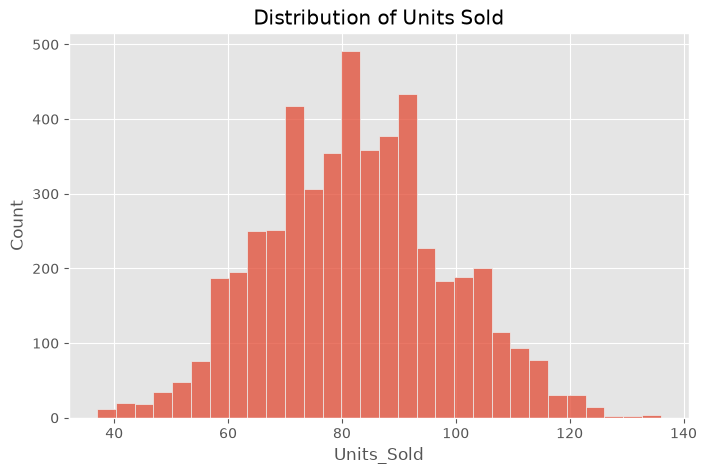

In [8]:
plt.figure(figsize=(8,5))  #Distribution of sales

sns.histplot(df["Units_Sold"], bins=30)

plt.title("Distribution of Units Sold")
plt.show()

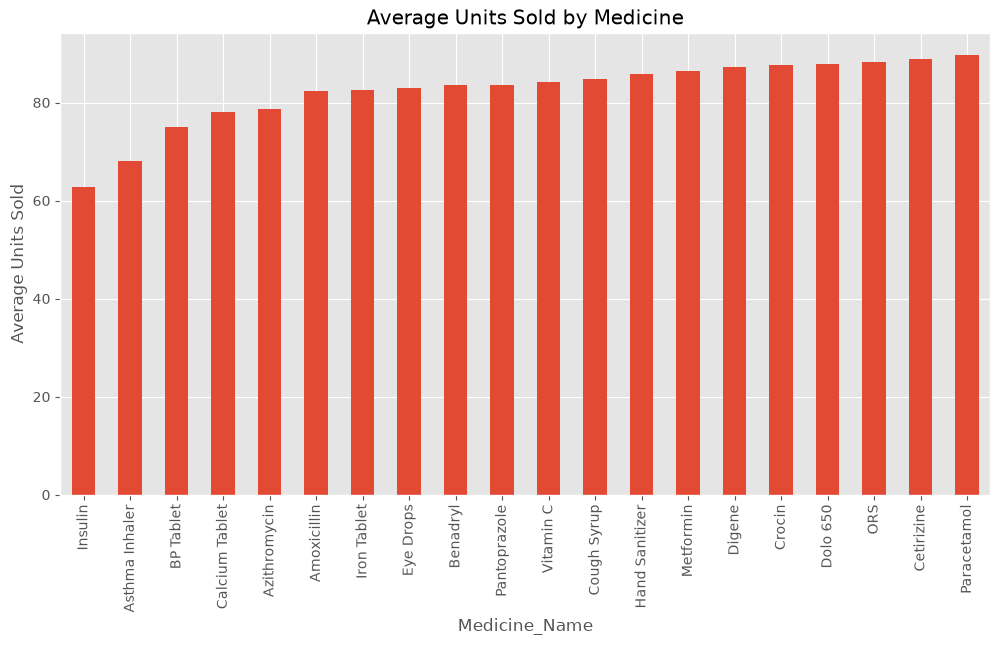

In [9]:
plt.figure(figsize=(12,6))  #Sales by medicine

df.groupby("Medicine_Name")["Units_Sold"].mean().sort_values().plot(kind="bar")

plt.title("Average Units Sold by Medicine")

plt.ylabel("Average Units Sold")

plt.show()

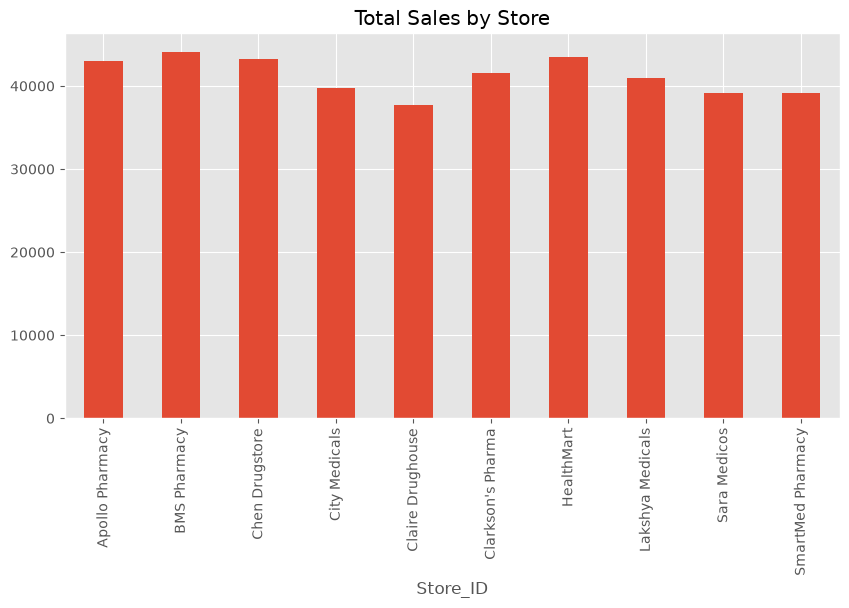

In [10]:
plt.figure(figsize=(10,5)) #Sales by store

df.groupby("Store_ID")["Units_Sold"].sum().plot(kind="bar")

plt.title("Total Sales by Store")

plt.show()

In [11]:
#Correlation heatmap
numeric_df = df.select_dtypes(include=["number"])

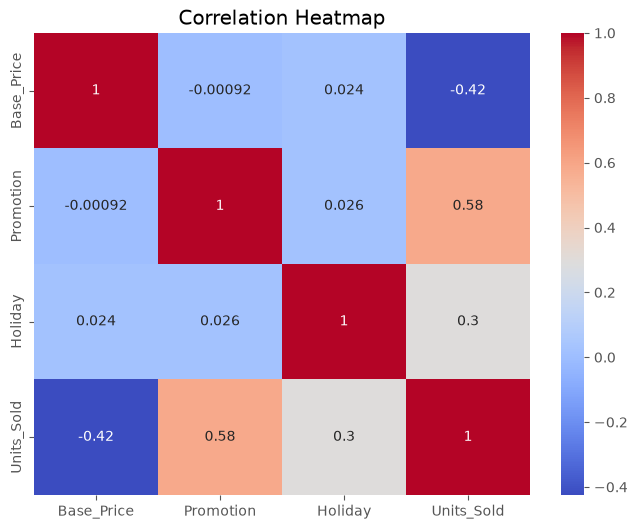

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

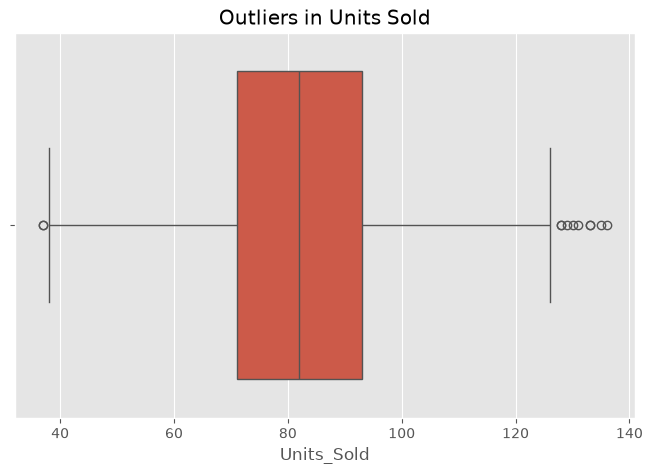

In [13]:
#Detect outliers
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Units_Sold"])

plt.title("Outliers in Units Sold")

plt.show()